# Code Clustering Analysis - WITHOUT TESTS (Excluding Cluster 9)

This notebook performs clustering and dimensionality reduction on code snippets **excluding test files**:
- **Dataset**: Raw codes filtered to remove Criterion test scripts (cluster 9)
- **Encoder**: Salesforce/SFR-Embedding-Code-400M
- **Clustering**: K-Means
- **Visualization**: t-SNE only

Goal: Analyze semantic groupings of production code without test noise

## 1. Setup and Imports

In [1]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
from typing import List, Dict
import warnings
warnings.filterwarnings('ignore')

# Embeddings
from sentence_transformers import SentenceTransformer
import torch

# Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Dimensionality reduction
from sklearn.manifold import TSNE

# Visualization
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'}")

PyTorch version: 2.9.1
Device: mps


## 2. Filter Dataset - Remove Test Scripts (Cluster 9)

In [2]:
print("="*100)
print("FILTERING DATASET: REMOVING TEST SCRIPTS")
print("="*100)
print()

# Load the clustered dataset to identify cluster 9
df_clustered = pd.read_csv('../data/dataset_clustered.csv')
print(f"Original dataset: {len(df_clustered)} samples")
print(f"Cluster 9 (test scripts with criterion): {len(df_clustered[df_clustered['cluster_kmeans'] == 9])} samples")

# Get code_ids to keep (all except cluster 9)
code_ids_to_keep = set(df_clustered[df_clustered['cluster_kmeans'] != 9]['code_id'].tolist())
print(f"\nCode IDs to keep: {len(code_ids_to_keep)}")

# Load original JSONL
data = []
with open('../data/raw_dataset.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        if line.strip():
            data.append(json.loads(line))

print(f"Original JSONL: {len(data)} samples")

# Filter data
filtered_data = [item for item in data if item['code_id'] in code_ids_to_keep]
print(f"\n✓ Filtered dataset (WITHOUT TESTS): {len(filtered_data)} samples")
print(f"  Removed: {len(data) - len(filtered_data)} test scripts")

# Save filtered JSONL
output_jsonl = Path('../data/raw_dataset_no_tests.jsonl')
with open(output_jsonl, 'w', encoding='utf-8') as f:
    for item in filtered_data:
        f.write(json.dumps(item, ensure_ascii=False) + '\n')

print(f"\n✓ Saved filtered dataset to: {output_jsonl}")
print("\n" + "="*100)

FILTERING DATASET: REMOVING TEST SCRIPTS

Original dataset: 14578 samples
Cluster 9 (test scripts with criterion): 2346 samples

Code IDs to keep: 12232
Original JSONL: 14578 samples

✓ Filtered dataset (WITHOUT TESTS): 12232 samples
  Removed: 2346 test scripts

✓ Saved filtered dataset to: ../data/raw_dataset_no_tests.jsonl



## 3. Load Filtered Data (Codes WITHOUT Tests)

In [3]:
# Load filtered dataset
dataset_path = Path('../data/raw_dataset_no_tests.jsonl')

data = []
with open(dataset_path, 'r', encoding='utf-8') as f:
    for line in f:
        if line.strip():
            data.append(json.loads(line))

print(f"Loaded {len(data)} code snippets (WITHOUT TESTS)")

# Convert to DataFrame
df = pd.DataFrame(data)
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst entry:")
print(df.iloc[0]['code_snippet'][:200])

Loaded 12232 code snippets (WITHOUT TESTS)

Columns: ['code_id', 'author_id', 'code_snippet', 'generated_feedback']

First entry:
int recursive_factorial(int nb)
{
    if (nb == 0) {
        return (1);
    } else {
        return (nb * recursive_factorial(nb - 1));
    }
}

int my_compute_factorial_rec(int nb)
{
    if (nb == 0


## 4. Load Code Encoder

In [4]:
MODEL_NAME = "Salesforce/SFR-Embedding-Code-400M_R"

print(f"Loading model: {MODEL_NAME}")

# Set device
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

print(f"Using device: {device}")

# Load model
model = SentenceTransformer(MODEL_NAME, device=device, trust_remote_code=True)

print(f"Model loaded successfully!")
print(f"Embedding dimension: {model.get_sentence_embedding_dimension()}")

Loading model: Salesforce/SFR-Embedding-Code-400M_R
Using device: mps
Model loaded successfully!
Embedding dimension: 1024


## 5. Generate Embeddings (Codes WITHOUT Tests)

In [5]:
# Extract code snippets
code_snippets = df['code_snippet'].tolist()

# Check if embeddings already exist
embeddings_path = Path('../data/code_embeddings_no_tests.npy')

if embeddings_path.exists():
    print(f"✓ Loading existing embeddings from: {embeddings_path}")
    embeddings = np.load(embeddings_path)
    print(f"Embeddings shape: {embeddings.shape}")
else:
    print(f"Generating embeddings for {len(code_snippets)} code snippets (WITHOUT TESTS)...")
    print("This may take a few minutes...\n")
    
    # Generate embeddings with batching
    embeddings = model.encode(
        code_snippets,
        batch_size=4,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True  # L2 normalize for better clustering
    )
    
    print(f"\nEmbeddings shape: {embeddings.shape}")
    
    # Save embeddings
    np.save(embeddings_path, embeddings)
    print(f"✓ Embeddings saved to: {embeddings_path}")

# Add to dataframe
df['embedding'] = list(embeddings)

Generating embeddings for 12232 code snippets (WITHOUT TESTS)...
This may take a few minutes...



Batches:   0%|          | 0/3058 [00:00<?, ?it/s]


Embeddings shape: (12232, 1024)
✓ Embeddings saved to: ../data/code_embeddings_no_tests.npy


## 6. K-Means Clustering (Codes WITHOUT Tests)

### 6.1 Find Optimal Number of Clusters

Testing different values of k (WITHOUT TESTS)...


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


k= 5: inertia=2285.37, silhouette=0.208
k=10: inertia=1689.31, silhouette=0.283
k=15: inertia=1474.30, silhouette=0.256
k=20: inertia=1340.74, silhouette=0.227
k=25: inertia=1236.56, silhouette=0.232
k=30: inertia=1163.03, silhouette=0.226


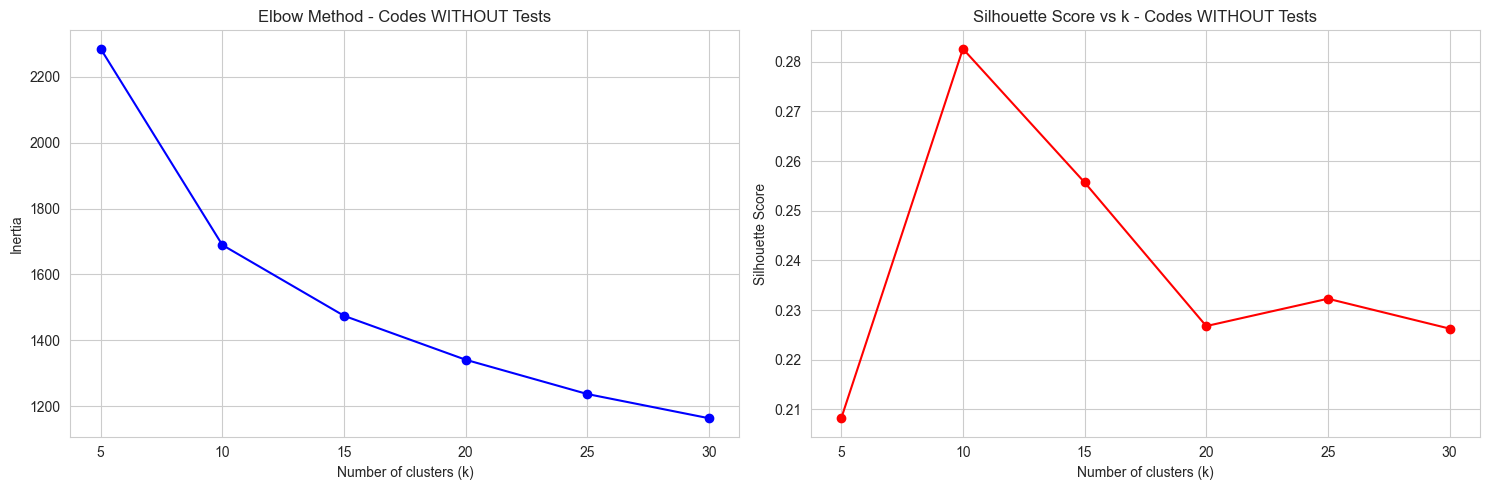


Optimal k (by silhouette score): 10


In [6]:
# Find optimal number of clusters using elbow method
k_range = range(5, 31, 5)
inertias = []
silhouette_scores = []

print("Testing different values of k (WITHOUT TESTS)...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(embeddings)
    
    inertias.append(kmeans.inertia_)
    sil_score = silhouette_score(embeddings, labels)
    silhouette_scores.append(sil_score)
    
    print(f"k={k:2d}: inertia={kmeans.inertia_:.2f}, silhouette={sil_score:.3f}")

# Plot elbow curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(k_range, inertias, 'bo-')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method - Codes WITHOUT Tests')
ax1.grid(True)

ax2.plot(k_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score vs k - Codes WITHOUT Tests')
ax2.grid(True)

plt.tight_layout()
plt.show()

# Choose optimal k
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"\nOptimal k (by silhouette score): {optimal_k}")

### 6.2 Perform K-Means with Optimal k

In [7]:
N_CLUSTERS = optimal_k  # Or set manually

print(f"Performing K-Means clustering with k={N_CLUSTERS} (WITHOUT TESTS)...")
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=20)
df['cluster_kmeans'] = kmeans.fit_predict(embeddings)

# Cluster statistics
print(f"\nCluster distribution (WITHOUT TESTS):")
print(df['cluster_kmeans'].value_counts().sort_index())

Performing K-Means clustering with k=10 (WITHOUT TESTS)...

Cluster distribution (WITHOUT TESTS):
cluster_kmeans
0     921
1    1736
2     646
3    1715
4    1452
5     909
6     883
7     982
8     937
9    2051
Name: count, dtype: int64


## 7. t-SNE Visualization (Codes WITHOUT Tests)

In [8]:
# t-SNE reduction
print("Performing t-SNE dimensionality reduction (WITHOUT TESTS)...")
print("This may take several minutes...\n")

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    verbose=1
)

tsne_coords = tsne.fit_transform(embeddings)
df['tsne_x'] = tsne_coords[:, 0]
df['tsne_y'] = tsne_coords[:, 1]

print("\nt-SNE completed!")

Performing t-SNE dimensionality reduction (WITHOUT TESTS)...
This may take several minutes...

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 12232 samples in 0.002s...
[t-SNE] Computed neighbors for 12232 samples in 0.693s...
[t-SNE] Computed conditional probabilities for sample 1000 / 12232
[t-SNE] Computed conditional probabilities for sample 2000 / 12232
[t-SNE] Computed conditional probabilities for sample 3000 / 12232
[t-SNE] Computed conditional probabilities for sample 4000 / 12232
[t-SNE] Computed conditional probabilities for sample 5000 / 12232
[t-SNE] Computed conditional probabilities for sample 6000 / 12232
[t-SNE] Computed conditional probabilities for sample 7000 / 12232
[t-SNE] Computed conditional probabilities for sample 8000 / 12232
[t-SNE] Computed conditional probabilities for sample 9000 / 12232
[t-SNE] Computed conditional probabilities for sample 10000 / 12232
[t-SNE] Computed conditional probabilities for sample 11000 / 12232
[t-SNE] Computed condit

## 8. Interactive t-SNE Visualization (Codes WITHOUT Tests)

In [9]:
# Prepare hover text
df['hover_text'] = df.apply(
    lambda x: f"<b>Cluster {x['cluster_kmeans']}</b><br>" + 
              f"Code ID: {x['code_id'][:8]}...<br><br>" +
              f"<i>{x['code_snippet'][:150]}...</i>",
    axis=1
)

# Convert cluster to string for discrete colors
df['cluster_str'] = df['cluster_kmeans'].astype(str)

# Define distinct colors
discrete_colors = [
    '#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231',
    '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe',
    '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000',
    '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080'
]

# Create interactive plot
fig = px.scatter(
    df,
    x='tsne_x',
    y='tsne_y',
    color='cluster_str',
    hover_data={'hover_text': True, 'tsne_x': False, 'tsne_y': False, 'cluster_str': False},
    title=f't-SNE Visualization - Codes WITHOUT TESTS (K-Means, k={N_CLUSTERS})',
    labels={'cluster_str': 'Cluster'},
    color_discrete_sequence=discrete_colors,
    width=1000,
    height=700
)

fig.update_traces(marker=dict(size=5, opacity=0.8))
fig.update_layout(
    font=dict(size=12),
    hoverlabel=dict(bgcolor="white", font_size=11),
    legend=dict(
        title=dict(text='Cluster', font=dict(size=14)),
        font=dict(size=12)
    )
)

fig.write_html("t-sne_codes_no_tests.html")
print("✓ Visualization saved to: t-sne_codes_no_tests.html")
fig.show()

✓ Visualization saved to: t-sne_codes_no_tests.html


## 9. Cluster Analysis (Codes WITHOUT Tests)

### 9.1 Cluster Sizes

In [10]:
# Visualize cluster sizes
cluster_sizes = df['cluster_kmeans'].value_counts().sort_index()

fig = px.bar(
    x=cluster_sizes.index,
    y=cluster_sizes.values,
    title='Code Distribution Across Clusters (WITHOUT TESTS)',
    labels={'x': 'Cluster ID', 'y': 'Number of Code Snippets'},
    color=cluster_sizes.values,
    color_continuous_scale='Blues'
)

fig.update_layout(showlegend=False, height=500)
fig.show()

### 9.2 Cluster Representatives

In [11]:
# Get representative samples from each cluster
def get_cluster_representatives(df, embeddings, cluster_col, n_samples=3):
    """Get samples closest to cluster centroids."""
    representatives = []
    
    for cluster_id in sorted(df[cluster_col].unique()):
        cluster_mask = df[cluster_col] == cluster_id
        cluster_embeddings = embeddings[cluster_mask]
        cluster_indices = df[cluster_mask].index
        
        # Calculate centroid
        centroid = cluster_embeddings.mean(axis=0)
        
        # Find closest points
        distances = np.linalg.norm(cluster_embeddings - centroid, axis=1)
        closest_idx = np.argsort(distances)[:n_samples]
        
        for idx in closest_idx:
            representatives.append({
                'cluster': cluster_id,
                'code': df.loc[cluster_indices[idx], 'code_snippet'],
                'distance_to_centroid': distances[idx]
            })
    
    return representatives

representatives = get_cluster_representatives(df, embeddings, 'cluster_kmeans', n_samples=2)

# Display representatives
print("CLUSTER REPRESENTATIVES (Codes WITHOUT TESTS)")
print("="*80)

for rep in representatives:
    print(f"\n{'='*80}")
    print(f"CLUSTER {rep['cluster']} (distance: {rep['distance_to_centroid']:.4f})")
    print(f"{'='*80}")
    print(rep['code'][:300])
    if len(rep['code']) > 300:
        print("...")

CLUSTER REPRESENTATIVES (Codes WITHOUT TESTS)

CLUSTER 0 (distance: 0.2111)
int my_is_prime(int nb)
{
    int i = 2;

    if (nb == 2) {
        return (1);
    }
    if (nb <= 1) {
        return (0);
    }
    while (nb % i > 0) {
        i++;
        if (i == nb) {
            return (1);
        }
    }
    return (0);
}

CLUSTER 0 (distance: 0.2137)
int my_is_prime(int nb)
{
    int i = 2;

    if (nb < 0) {
        return (0);
    }
    if (nb == 0 || nb == 1) {
        return (0);
    }
    if (nb == 2) {
        return (1);
    }
    while ( i < nb) {
        if (nb % i != 0) {
            i++;
        } else {
            return (0);
      
...

CLUSTER 1 (distance: 0.1753)
char *my_strncpy(char *dest, char const *src, int n)
{
    int i = 0;

    while (i < n && src[i] != '\0') {
        dest[i] = src[i];
        i++;
    }
    dest[i] = '\0';
    return dest;
}

CLUSTER 1 (distance: 0.1763)
#include <unistd.h>

char *my_strncpy(char *dest , char const *src , int n)
{
    int

## 10. TF-IDF Keywords per Cluster (Codes WITHOUT Tests)

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
import re

def extract_tokens(code):
    """Extract meaningful tokens from code."""
    code = re.sub(r'//.*?$|/\*.*?\*/|".*?"|\'.?\'', '', code, flags=re.MULTILINE | re.DOTALL)
    tokens = re.findall(r'\b[a-zA-Z_][a-zA-Z0-9_]*\b', code)
    return ' '.join(tokens)

df['tokens'] = df['code_snippet'].apply(extract_tokens)

def get_cluster_keywords(df, cluster_col='cluster_kmeans', top_n=10):
    """Extract top TF-IDF keywords for each cluster."""
    cluster_keywords = {}
    
    for cluster_id in sorted(df[cluster_col].unique()):
        cluster_codes = df[df[cluster_col] == cluster_id]['tokens'].tolist()
        
        if len(cluster_codes) < 2:
            continue
        
        all_other_codes = df[df[cluster_col] != cluster_id]['tokens'].tolist()
        cluster_doc = ' '.join(cluster_codes)
        corpus = [cluster_doc, ' '.join(all_other_codes)]
        
        vectorizer = TfidfVectorizer(max_features=500, stop_words=None)
        tfidf_matrix = vectorizer.fit_transform(corpus)
        feature_names = vectorizer.get_feature_names_out()
        
        cluster_scores = tfidf_matrix[0].toarray()[0]
        top_indices = np.argsort(cluster_scores)[::-1][:top_n]
        top_keywords = [(feature_names[i], cluster_scores[i]) for i in top_indices if cluster_scores[i] > 0]
        
        cluster_keywords[cluster_id] = top_keywords
    
    return cluster_keywords

print("Computing TF-IDF keywords per cluster (WITHOUT TESTS)...")
cluster_keywords = get_cluster_keywords(df, 'cluster_kmeans', top_n=15)

print("\n" + "="*100)
print("TOP KEYWORDS PER CLUSTER (Codes WITHOUT TESTS)")
print("="*100)

for cluster_id, keywords in cluster_keywords.items():
    print(f"\nCluster {cluster_id} ({len(df[df['cluster_kmeans'] == cluster_id])} samples)")
    print("-"*100)
    
    if keywords:
        keyword_str = ", ".join([f"{kw} ({score:.3f})" for kw, score in keywords[:10]])
        print(f"Keywords: {keyword_str}")
    else:
        print("No distinctive keywords found")
    
    sample_code = df[df['cluster_kmeans'] == cluster_id].iloc[0]['code_snippet']
    print(f"\nSample code:")
    print(sample_code[:200] + ("..." if len(sample_code) > 200 else ""))
    print()

Computing TF-IDF keywords per cluster (WITHOUT TESTS)...

TOP KEYWORDS PER CLUSTER (Codes WITHOUT TESTS)

Cluster 0 (921 samples)
----------------------------------------------------------------------------------------------------
Keywords: nb (0.699), int (0.489), return (0.401), if (0.287), my_is_prime (0.103), while (0.073), my_find_prime_sup (0.064), for (0.060), prime (0.036), else (0.034)

Sample code:
int my_find_prime_sup(int nb)
{
    int isprime = my_is_prime(nb);

    if (nb <= 2) {
        return (2);
    }
    while (isprime == 0) {
        nb++;
        isprime = my_is_prime(nb);
    }
    r...


Cluster 1 (1736 samples)
----------------------------------------------------------------------------------------------------
Keywords: dest (0.603), char (0.480), src (0.455), int (0.309), return (0.178), const (0.166), while (0.120), my_strncpy (0.081), for (0.073), my_strcpy (0.066)

Sample code:
char *my_strncpy(char *dest, char const *src, int n)
{
    for (int i = 0; i < n;

## 11. High-Dimensional Cohesion Analysis (Codes WITHOUT Tests)

Computing cluster cohesion metrics (WITHOUT TESTS)...

CLUSTER COHESION ANALYSIS - Codes WITHOUT TESTS (1024D)

 cluster  n_samples  mean_radius  std_radius  mean_pairwise_dist  std_pairwise_dist  diameter  cohesion_score
       0        921     0.339350    0.076233            0.477266           0.120083  0.825528        0.014915
       1       1736     0.275962    0.066831            0.388427           0.102275  0.790923        0.012138
       2        646     0.301053    0.087021            0.430148           0.108113  0.875312        0.013442
       3       1715     0.305320    0.070752            0.427971           0.115792  0.851491        0.013374
       4       1452     0.422363    0.066982            0.593863           0.115469  0.945620        0.018558
       5        909     0.368403    0.061307            0.515823           0.114860  0.865135        0.016119
       6        883     0.438412    0.043830            0.606757           0.143313  0.932140        0.018961
       7

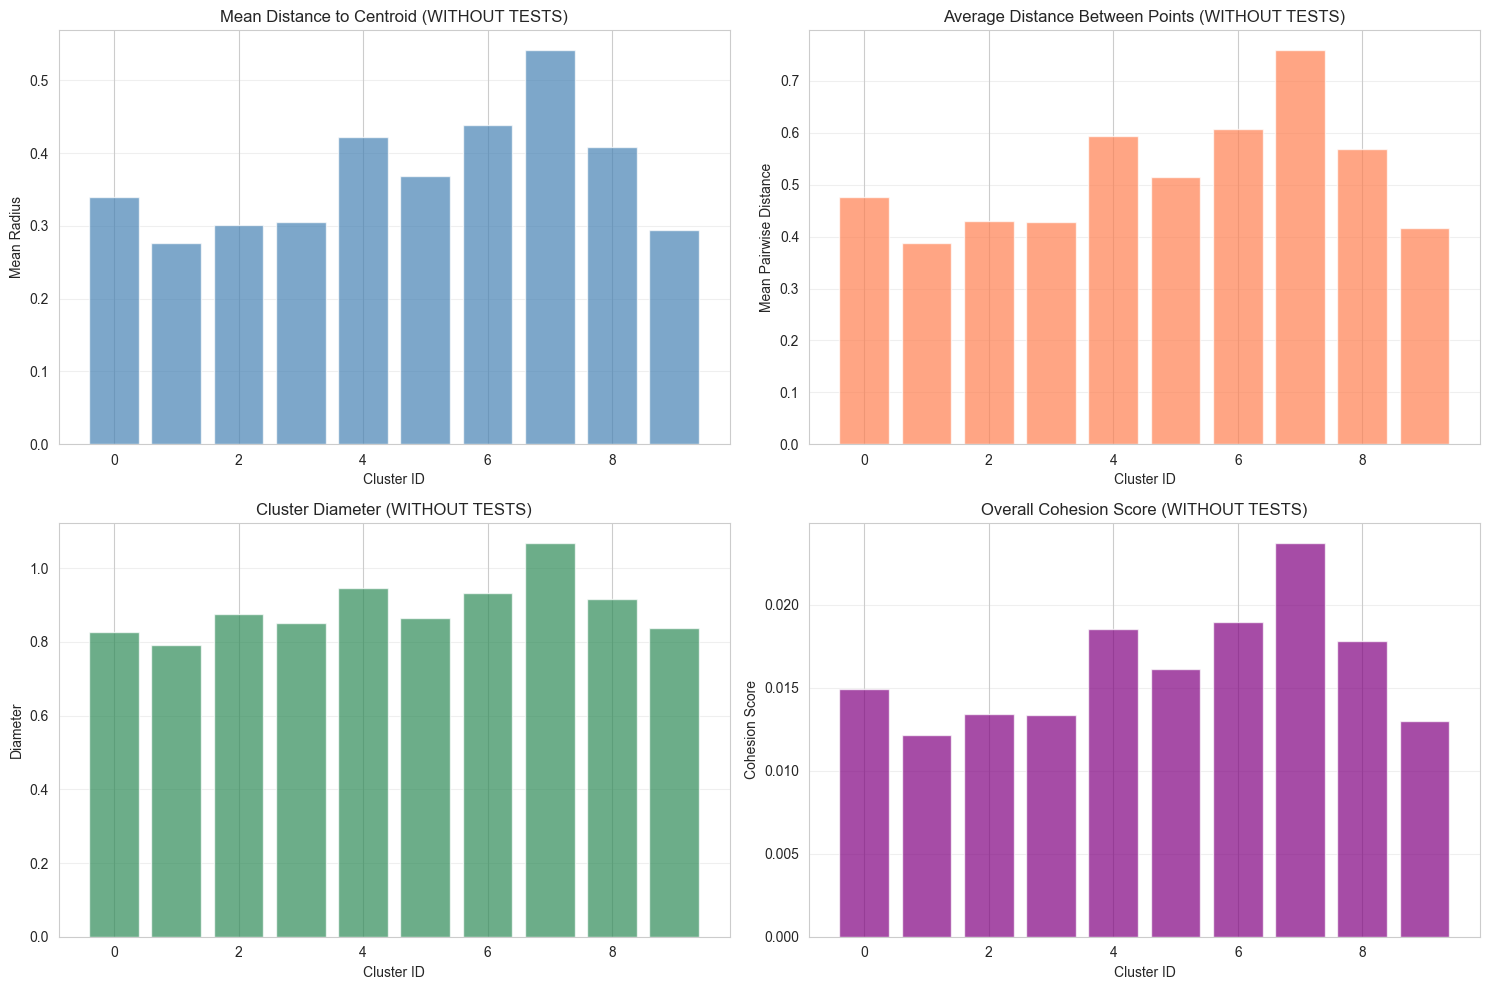


Most compact: Cluster 1 (score: 0.0121)
Most dispersed: Cluster 7 (score: 0.0237)
Average: 0.0162 ± 0.0036


In [13]:
from scipy.spatial.distance import pdist

def compute_cluster_cohesion_metrics(embeddings, labels):
    """Compute cohesion metrics for each cluster in high-D space."""
    metrics = []
    
    for cluster_id in sorted(np.unique(labels)):
        cluster_mask = labels == cluster_id
        cluster_emb = embeddings[cluster_mask]
        n_samples = len(cluster_emb)
        
        if n_samples < 2:
            continue
        
        centroid = cluster_emb.mean(axis=0)
        distances_to_centroid = np.linalg.norm(cluster_emb - centroid, axis=1)
        mean_radius = distances_to_centroid.mean()
        std_radius = distances_to_centroid.std()
        
        pairwise_dists = pdist(cluster_emb, metric='euclidean')
        mean_pairwise = pairwise_dists.mean()
        std_pairwise = pairwise_dists.std()
        diameter = pairwise_dists.max()
        
        cohesion_score = mean_pairwise / np.sqrt(cluster_emb.shape[1])
        
        metrics.append({
            'cluster': cluster_id,
            'n_samples': n_samples,
            'mean_radius': mean_radius,
            'std_radius': std_radius,
            'mean_pairwise_dist': mean_pairwise,
            'std_pairwise_dist': std_pairwise,
            'diameter': diameter,
            'cohesion_score': cohesion_score
        })
    
    return pd.DataFrame(metrics)

print("Computing cluster cohesion metrics (WITHOUT TESTS)...")
cohesion_df = compute_cluster_cohesion_metrics(embeddings, df['cluster_kmeans'].values)

print("\n" + "="*100)
print("CLUSTER COHESION ANALYSIS - Codes WITHOUT TESTS (1024D)")
print("="*100)
print()
print(cohesion_df.to_string(index=False))

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].bar(cohesion_df['cluster'], cohesion_df['mean_radius'], color='steelblue', alpha=0.7)
axes[0, 0].set_xlabel('Cluster ID')
axes[0, 0].set_ylabel('Mean Radius')
axes[0, 0].set_title('Mean Distance to Centroid (WITHOUT TESTS)')
axes[0, 0].grid(axis='y', alpha=0.3)

axes[0, 1].bar(cohesion_df['cluster'], cohesion_df['mean_pairwise_dist'], color='coral', alpha=0.7)
axes[0, 1].set_xlabel('Cluster ID')
axes[0, 1].set_ylabel('Mean Pairwise Distance')
axes[0, 1].set_title('Average Distance Between Points (WITHOUT TESTS)')
axes[0, 1].grid(axis='y', alpha=0.3)

axes[1, 0].bar(cohesion_df['cluster'], cohesion_df['diameter'], color='seagreen', alpha=0.7)
axes[1, 0].set_xlabel('Cluster ID')
axes[1, 0].set_ylabel('Diameter')
axes[1, 0].set_title('Cluster Diameter (WITHOUT TESTS)')
axes[1, 0].grid(axis='y', alpha=0.3)

axes[1, 1].bar(cohesion_df['cluster'], cohesion_df['cohesion_score'], color='purple', alpha=0.7)
axes[1, 1].set_xlabel('Cluster ID')
axes[1, 1].set_ylabel('Cohesion Score')
axes[1, 1].set_title('Overall Cohesion Score (WITHOUT TESTS)')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nMost compact: Cluster {cohesion_df.loc[cohesion_df['cohesion_score'].idxmin(), 'cluster']} (score: {cohesion_df['cohesion_score'].min():.4f})")
print(f"Most dispersed: Cluster {cohesion_df.loc[cohesion_df['cohesion_score'].idxmax(), 'cluster']} (score: {cohesion_df['cohesion_score'].max():.4f})")
print(f"Average: {cohesion_df['cohesion_score'].mean():.4f} ± {cohesion_df['cohesion_score'].std():.4f}")

## 12. Projection Fidelity Analysis (Codes WITHOUT Tests)

PROJECTION FIDELITY ANALYSIS - Codes WITHOUT TESTS

Analyzing t-SNE projection (WITHOUT TESTS)...
Computing pairwise distances for 2000 samples...

RESULTS: Distance Correlation (High-D ↔ 2D) - Codes WITHOUT TESTS

t-SNE: Spearman ρ = 0.5928 (p=0.00e+00)


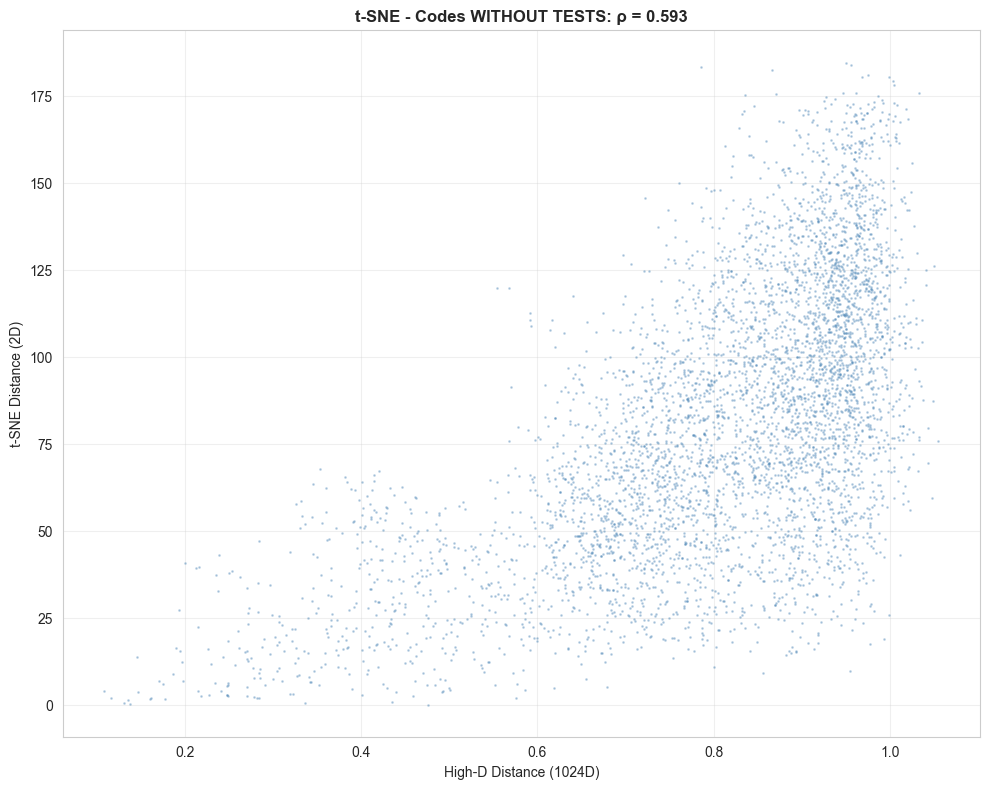

In [14]:
from scipy.stats import spearmanr, pearsonr

def compute_projection_fidelity(high_d_embeddings, low_d_coords, sample_size=2000):
    """Compute correlation between high-D and low-D distances."""
    n_samples = len(high_d_embeddings)
    
    if n_samples > sample_size:
        indices = np.random.choice(n_samples, size=sample_size, replace=False)
        high_d_sample = high_d_embeddings[indices]
        low_d_sample = low_d_coords[indices]
    else:
        high_d_sample = high_d_embeddings
        low_d_sample = low_d_coords
    
    print(f"Computing pairwise distances for {len(high_d_sample)} samples...")
    high_d_dists = pdist(high_d_sample, metric='euclidean')
    low_d_dists = pdist(low_d_sample, metric='euclidean')
    
    spearman_corr, spearman_p = spearmanr(high_d_dists, low_d_dists)
    pearson_corr, pearson_p = pearsonr(high_d_dists, low_d_dists)
    
    return {
        'spearman': spearman_corr,
        'spearman_p': spearman_p,
        'pearson': pearson_corr,
        'pearson_p': pearson_p,
        'high_d_dists': high_d_dists,
        'low_d_dists': low_d_dists
    }

print("="*100)
print("PROJECTION FIDELITY ANALYSIS - Codes WITHOUT TESTS")
print("="*100)
print()

tsne_coords = df[['tsne_x', 'tsne_y']].values

print("Analyzing t-SNE projection (WITHOUT TESTS)...")
tsne_fidelity = compute_projection_fidelity(embeddings, tsne_coords, sample_size=2000)

print("\n" + "="*100)
print("RESULTS: Distance Correlation (High-D ↔ 2D) - Codes WITHOUT TESTS")
print("="*100)
print(f"\nt-SNE: Spearman ρ = {tsne_fidelity['spearman']:.4f} (p={tsne_fidelity['spearman_p']:.2e})")

# Scatter plot
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

subsample = np.random.choice(len(tsne_fidelity['high_d_dists']), 
                             size=min(5000, len(tsne_fidelity['high_d_dists'])), 
                             replace=False)

ax.scatter(tsne_fidelity['high_d_dists'][subsample], 
           tsne_fidelity['low_d_dists'][subsample], 
           alpha=0.3, s=1, c='steelblue')
ax.set_xlabel('High-D Distance (1024D)')
ax.set_ylabel('t-SNE Distance (2D)')
ax.set_title(f't-SNE - Codes WITHOUT TESTS: ρ = {tsne_fidelity["spearman"]:.3f}', fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 13. Semantic Entropy & Information Compression (Codes WITHOUT Tests)

SEMANTIC ENTROPY & INFORMATION COMPRESSION - Codes WITHOUT TESTS

Per-Cluster Semantic Diversity (WITHOUT TESTS):
 cluster  n_samples  intra_variance  mean_intra_dist  entropy_normalized
       0        921        0.120970         0.477266            0.355336
       1       1736        0.080622         0.388427            0.236817
       2        646        0.098206         0.430148            0.288468
       3       1715        0.098226         0.427971            0.288529
       4       1452        0.182877         0.593863            0.537180
       5        909        0.139479         0.515823            0.409704
       6        883        0.194126         0.606757            0.570223
       7        982        0.296443         0.759471            0.870769
       8        937        0.170943         0.569477            0.502125
       9       2051        0.093138         0.415823            0.273581

GLOBAL COMPRESSION METRICS - Codes WITHOUT TESTS
Variance explained: 59.43%
Compre

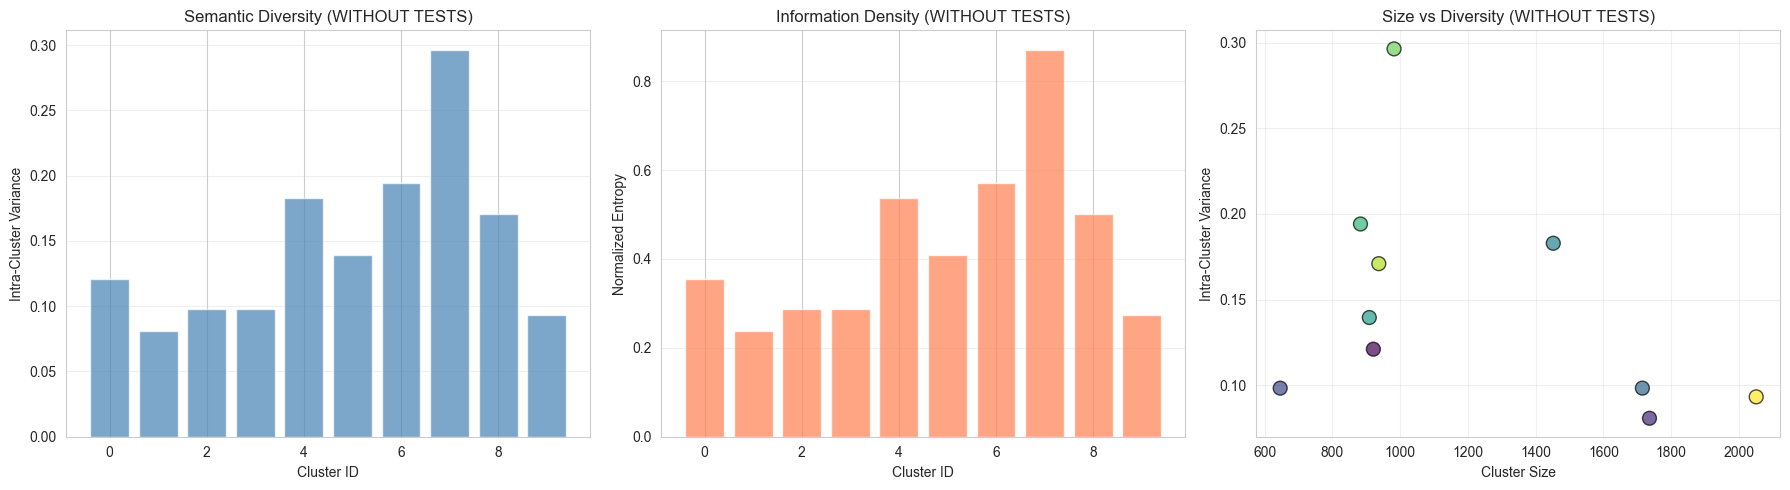

In [15]:
def compute_semantic_entropy(embeddings, labels):
    """Compute variance-based compression metrics."""
    metrics = []
    unique_labels = sorted([l for l in np.unique(labels) if l != -1])
    
    global_centroid = embeddings.mean(axis=0)
    total_variance = np.var(embeddings, axis=0).sum()
    
    centroids = []
    for cluster_id in unique_labels:
        cluster_emb = embeddings[labels == cluster_id]
        centroids.append(cluster_emb.mean(axis=0))
    
    centroids = np.array(centroids)
    inter_cluster_dists = pdist(centroids, metric='euclidean')
    mean_inter_cluster = inter_cluster_dists.mean()
    
    within_cluster_variance = 0
    between_cluster_variance = 0
    
    for cluster_id in unique_labels:
        cluster_mask = labels == cluster_id
        cluster_emb = embeddings[cluster_mask]
        n_samples = len(cluster_emb)
        
        if n_samples < 2:
            continue
        
        centroid = cluster_emb.mean(axis=0)
        intra_variance = np.sum(np.var(cluster_emb, axis=0))
        within_cluster_variance += intra_variance * n_samples
        
        between_variance = np.sum((centroid - global_centroid) ** 2)
        between_cluster_variance += between_variance * n_samples
        
        pairwise_dists = pdist(cluster_emb, metric='euclidean')
        
        metrics.append({
            'cluster': cluster_id,
            'n_samples': n_samples,
            'intra_variance': intra_variance,
            'mean_intra_dist': pairwise_dists.mean(),
            'entropy_normalized': intra_variance / total_variance
        })
    
    metrics_df = pd.DataFrame(metrics)
    
    within_cluster_variance /= len(embeddings)
    between_cluster_variance /= len(embeddings)
    variance_explained = between_cluster_variance / (within_cluster_variance + between_cluster_variance)
    compression_ratio = metrics_df['mean_intra_dist'].mean() / mean_inter_cluster
    
    summary = {
        'within_cluster_variance': within_cluster_variance,
        'between_cluster_variance': between_cluster_variance,
        'variance_explained': variance_explained,
        'mean_inter_cluster_dist': mean_inter_cluster,
        'mean_intra_cluster_dist': metrics_df['mean_intra_dist'].mean(),
        'compression_ratio': compression_ratio,
        'n_clusters': len(unique_labels)
    }
    
    return metrics_df, summary

print("="*100)
print("SEMANTIC ENTROPY & INFORMATION COMPRESSION - Codes WITHOUT TESTS")
print("="*100)
print()

entropy_metrics, compression_summary = compute_semantic_entropy(embeddings, df['cluster_kmeans'].values)

print("Per-Cluster Semantic Diversity (WITHOUT TESTS):")
print(entropy_metrics.to_string(index=False))
print()
print("="*100)
print("GLOBAL COMPRESSION METRICS - Codes WITHOUT TESTS")
print("="*100)
print(f"Variance explained: {compression_summary['variance_explained']*100:.2f}%")
print(f"Compression ratio: {compression_summary['compression_ratio']:.4f}")
print(f"Dimensionality: {embeddings.shape[1]}D → {compression_summary['n_clusters']} clusters")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(entropy_metrics['cluster'], entropy_metrics['intra_variance'], color='steelblue', alpha=0.7)
axes[0].set_xlabel('Cluster ID')
axes[0].set_ylabel('Intra-Cluster Variance')
axes[0].set_title('Semantic Diversity (WITHOUT TESTS)')
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(entropy_metrics['cluster'], entropy_metrics['entropy_normalized'], color='coral', alpha=0.7)
axes[1].set_xlabel('Cluster ID')
axes[1].set_ylabel('Normalized Entropy')
axes[1].set_title('Information Density (WITHOUT TESTS)')
axes[1].grid(axis='y', alpha=0.3)

axes[2].scatter(entropy_metrics['n_samples'], entropy_metrics['intra_variance'], 
                c=entropy_metrics['cluster'], cmap='viridis', s=100, alpha=0.7, edgecolors='black')
axes[2].set_xlabel('Cluster Size')
axes[2].set_ylabel('Intra-Cluster Variance')
axes[2].set_title('Size vs Diversity (WITHOUT TESTS)')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 14. Summary Statistics (Codes WITHOUT Tests)

In [16]:
print("="*100)
print("SCIENTIFIC SUMMARY: CLUSTERING QUALITY - Codes WITHOUT TESTS")
print("="*100)
print()

print("📊 DATASET INFORMATION")
print("-" * 100)
print(f"   Original dataset: 14,578 samples")
print(f"   Tests removed (cluster 9): 2,346 samples")
print(f"   Filtered dataset: {len(df)} samples (WITHOUT TESTS)")
print()

print("1️⃣  SEMANTIC COHERENCE (TF-IDF Keywords)")
print("-" * 100)
print("   Each cluster has distinctive keywords, confirming semantic grouping.")
print("   WITHOUT test-related keywords (criterion, cr_assert, etc.)")
print()

print("2️⃣  HIGH-DIMENSIONAL COHESION")
print("-" * 100)
print(f"   Average cohesion score: {cohesion_df['cohesion_score'].mean():.4f}")
print(f"   Best cluster: {cohesion_df['cohesion_score'].min():.4f}")
print(f"   Worst cluster: {cohesion_df['cohesion_score'].max():.4f}")
print()

print("3️⃣  PROJECTION FIDELITY")
print("-" * 100)
print(f"   t-SNE distance correlation: {tsne_fidelity['spearman']:.3f}")
print()

print("4️⃣  INFORMATION COMPRESSION")
print("-" * 100)
print(f"   Variance explained by clustering: {compression_summary['variance_explained']*100:.1f}%")
print(f"   Compression ratio: {compression_summary['compression_ratio']:.3f}")
print(f"   Dimensionality reduction: {embeddings.shape[1]}D → {compression_summary['n_clusters']} clusters")
print()

print("="*100)
print("CONCLUSION - Codes WITHOUT TESTS")
print("="*100)
print()
print(f"The {MODEL_NAME} embedding model successfully creates")
print("semantically coherent clusters for production code (WITHOUT TESTS):")
print()
print(f"  • {compression_summary['variance_explained']*100:.1f}% of variance explained by clustering")
print(f"  • Average within-cluster compactness: {cohesion_df['cohesion_score'].mean():.3f}")
print(f"  • {len(cohesion_df)} distinct semantic groups identified")
print()
print("="*100)

SCIENTIFIC SUMMARY: CLUSTERING QUALITY - Codes WITHOUT TESTS

📊 DATASET INFORMATION
----------------------------------------------------------------------------------------------------
   Original dataset: 14,578 samples
   Tests removed (cluster 9): 2,346 samples
   Filtered dataset: 12232 samples (WITHOUT TESTS)

1️⃣  SEMANTIC COHERENCE (TF-IDF Keywords)
----------------------------------------------------------------------------------------------------
   Each cluster has distinctive keywords, confirming semantic grouping.
   WITHOUT test-related keywords (criterion, cr_assert, etc.)

2️⃣  HIGH-DIMENSIONAL COHESION
----------------------------------------------------------------------------------------------------
   Average cohesion score: 0.0162
   Best cluster: 0.0121
   Worst cluster: 0.0237

3️⃣  PROJECTION FIDELITY
----------------------------------------------------------------------------------------------------
   t-SNE distance correlation: 0.593

4️⃣  INFORMATION COMPRESS

## 15. Save Results (Codes WITHOUT Tests)

In [17]:
# Save enriched dataset
output_path = Path('../data/dataset_clustered_no_tests.csv')

save_columns = [
    'code_id', 'author_id', 'code_snippet',
    'cluster_kmeans',
    'tsne_x', 'tsne_y'
]

if 'generated_feedback' in df.columns:
    save_columns.append('generated_feedback')

df[save_columns].to_csv(output_path, index=False)
print(f"✓ Clustered dataset (WITHOUT TESTS) saved to: {output_path}")

# Save embeddings
embeddings_path = Path('../data/code_embeddings_no_tests.npy')
np.save(embeddings_path, embeddings)
print(f"✓ Embeddings (WITHOUT TESTS) saved to: {embeddings_path}")

print("\n✓ Analysis complete!")

✓ Clustered dataset (WITHOUT TESTS) saved to: ../data/dataset_clustered_no_tests.csv
✓ Embeddings (WITHOUT TESTS) saved to: ../data/code_embeddings_no_tests.npy

✓ Analysis complete!


VISUALIZATION: String-Related Clusters in t-SNE Space



NameError: name 'string_clusters' is not defined

## 16. Deep Dive: String-Related Clusters Analysis

Based on TF-IDF analysis, several clusters appear to handle string operations:
- **Cluster 1**: String copying (`dest`, `src`) - strncpy, strcpy
- **Cluster 4**: General string operations (`str`, `to_find`, `my_strlen`) - revstr, strstr
- **Cluster 5**: String comparison (`s1`, `s2`) - strcmp, strncmp  
- **Cluster 6**: String property checks (`str`, `return`) - islower, isupper
- **Cluster 8**: String transformations (`str`) - strupcase, strlowcase

Let's analyze if these are truly distinct semantic groups or subcategories of a "string operations" meta-cluster.

### 16.1 Inter-Cluster Distance Matrix

In [19]:
from scipy.spatial.distance import cdist

# Define string-related clusters
string_clusters = [1, 4, 5, 6, 8]

print("="*100)
print("INTER-CLUSTER DISTANCE ANALYSIS: String-Related Clusters")
print("="*100)
print()

# Get centroids for each cluster
centroids = {}
for cluster_id in string_clusters:
    cluster_mask = df['cluster_kmeans'] == cluster_id
    cluster_emb = embeddings[cluster_mask]
    centroids[cluster_id] = cluster_emb.mean(axis=0)

# Compute pairwise distances between centroids
centroid_matrix = np.array([centroids[i] for i in string_clusters])
distances = cdist(centroid_matrix, centroid_matrix, metric='euclidean')

# Create distance dataframe
distance_df = pd.DataFrame(
    distances,
    index=[f'Cluster {i}' for i in string_clusters],
    columns=[f'Cluster {i}' for i in string_clusters]
)

print("Centroid Distance Matrix (Lower = More Similar):")
print(distance_df.round(4))
print()

# Compare to all other clusters
all_centroids = []
all_labels = []
for cluster_id in range(10):
    cluster_mask = df['cluster_kmeans'] == cluster_id
    cluster_emb = embeddings[cluster_mask]
    all_centroids.append(cluster_emb.mean(axis=0))
    all_labels.append(cluster_id)

all_centroid_matrix = np.array(all_centroids)
full_distances = cdist(all_centroid_matrix, all_centroid_matrix, metric='euclidean')

# Average distance between string clusters vs non-string clusters
string_indices = [i for i, label in enumerate(all_labels) if label in string_clusters]
non_string_indices = [i for i, label in enumerate(all_labels) if label not in string_clusters]

within_string_dists = []
for i in string_indices:
    for j in string_indices:
        if i < j:
            within_string_dists.append(full_distances[i, j])

string_to_nonstring_dists = []
for i in string_indices:
    for j in non_string_indices:
        string_to_nonstring_dists.append(full_distances[i, j])

print(f"Average distance WITHIN string-related clusters: {np.mean(within_string_dists):.4f}")
print(f"Average distance FROM string TO non-string clusters: {np.mean(string_to_nonstring_dists):.4f}")
print(f"Ratio (within/between): {np.mean(within_string_dists) / np.mean(string_to_nonstring_dists):.4f}")
print()

if np.mean(within_string_dists) < np.mean(string_to_nonstring_dists):
    ratio = np.mean(string_to_nonstring_dists) / np.mean(within_string_dists)
    print(f"✓ String clusters are {ratio:.2f}x closer to each other than to non-string clusters")
    print("  → They form a coherent 'string operations' meta-family")
else:
    print("⚠ String clusters are NOT significantly closer to each other")
    print("  → They may be semantically diverse despite similar domain")

INTER-CLUSTER DISTANCE ANALYSIS: String-Related Clusters

Centroid Distance Matrix (Lower = More Similar):
           Cluster 1  Cluster 4  Cluster 5  Cluster 6  Cluster 8
Cluster 1     0.0000     0.4421     0.5286     0.6516     0.5955
Cluster 4     0.4421     0.0000     0.4315     0.5319     0.4658
Cluster 5     0.5286     0.4315     0.0000     0.5777     0.5539
Cluster 6     0.6516     0.5319     0.5777     0.0000     0.3995
Cluster 8     0.5955     0.4658     0.5539     0.3995     0.0000

Average distance WITHIN string-related clusters: 0.5178
Average distance FROM string TO non-string clusters: 0.7278
Ratio (within/between): 0.7115

✓ String clusters are 1.41x closer to each other than to non-string clusters
  → They form a coherent 'string operations' meta-family


### 16.2 Hierarchical Clustering Visualization

HIERARCHICAL CLUSTERING: All Clusters



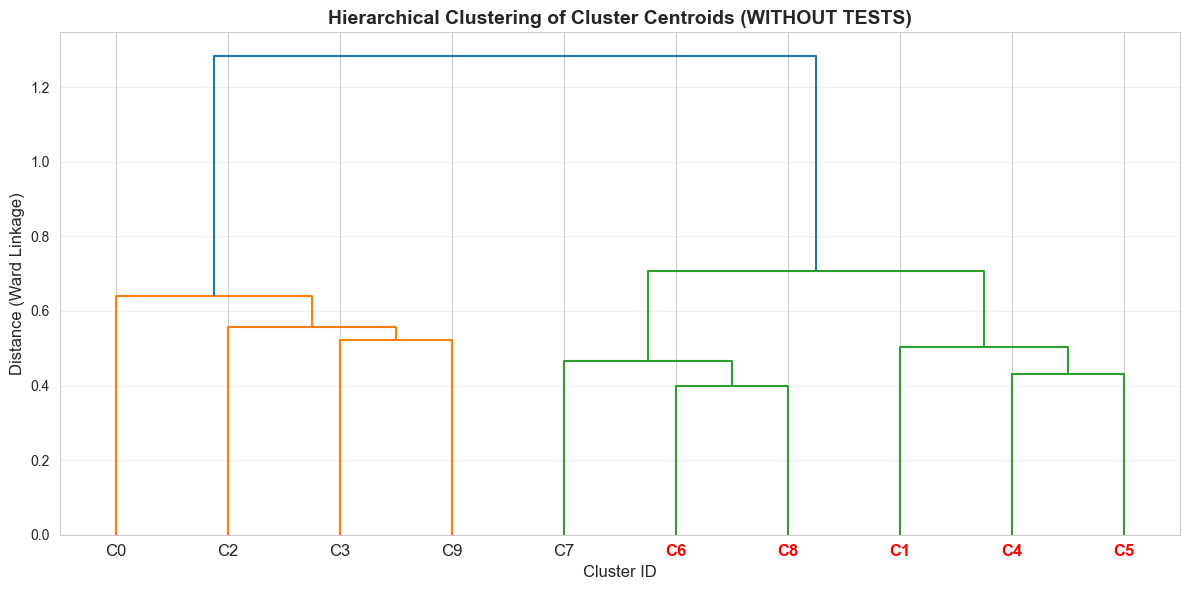

Red labels = String-related clusters
If they cluster together in the dendrogram, they share semantic proximity


In [20]:
from scipy.cluster.hierarchy import dendrogram, linkage

print("="*100)
print("HIERARCHICAL CLUSTERING: All Clusters")
print("="*100)
print()

# Compute linkage
all_centroid_matrix = np.array([
    embeddings[df['cluster_kmeans'] == i].mean(axis=0)
    for i in range(10)
])

linkage_matrix = linkage(all_centroid_matrix, method='ward')

# Plot dendrogram
fig, ax = plt.subplots(figsize=(12, 6))
dendrogram(
    linkage_matrix,
    labels=[f'C{i}' for i in range(10)],
    ax=ax,
    color_threshold=0.7 * max(linkage_matrix[:, 2])
)
ax.set_title('Hierarchical Clustering of Cluster Centroids (WITHOUT TESTS)', fontsize=14, fontweight='bold')
ax.set_xlabel('Cluster ID', fontsize=12)
ax.set_ylabel('Distance (Ward Linkage)', fontsize=12)
ax.grid(axis='y', alpha=0.3)

# Highlight string-related clusters
for label in ax.get_xticklabels():
    cluster_num = int(label.get_text().replace('C', ''))
    if cluster_num in string_clusters:
        label.set_color('red')
        label.set_weight('bold')

plt.tight_layout()
plt.show()

print("Red labels = String-related clusters")
print("If they cluster together in the dendrogram, they share semantic proximity")

### 16.3 Cosine Similarity Heatmap

COSINE SIMILARITY HEATMAP: All Clusters



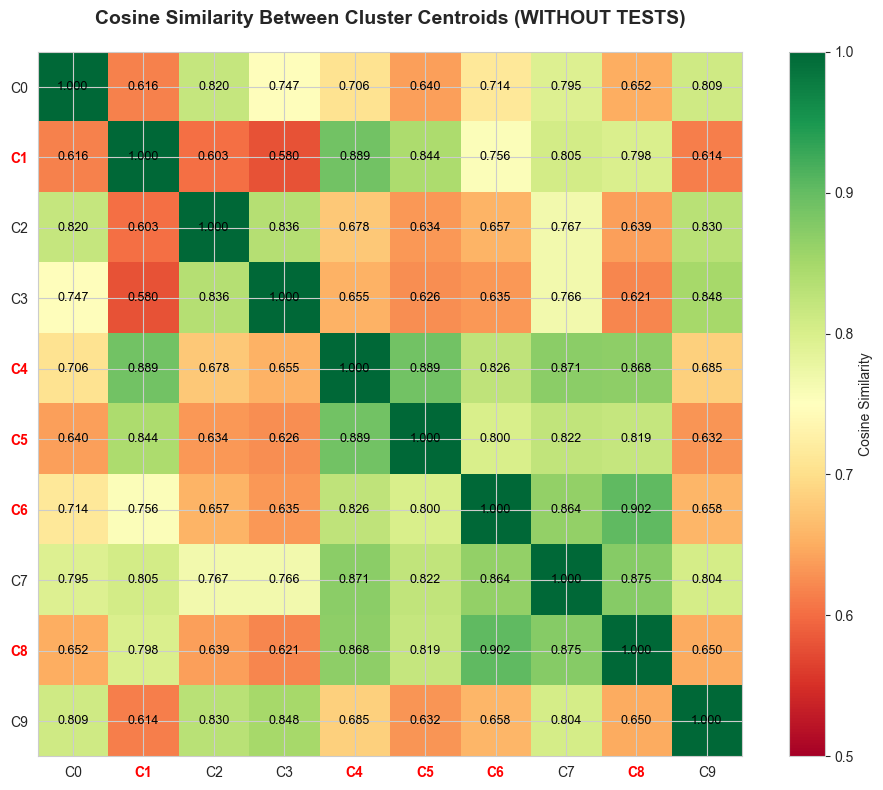

Red labels = String-related clusters
High similarity (green) indicates semantic proximity in 1024D space


In [21]:
from sklearn.metrics.pairwise import cosine_similarity

print("="*100)
print("COSINE SIMILARITY HEATMAP: All Clusters")
print("="*100)
print()

# Compute cosine similarity
all_centroids = np.array([
    embeddings[df['cluster_kmeans'] == i].mean(axis=0)
    for i in range(10)
])

similarity_matrix = cosine_similarity(all_centroids)

# Plot heatmap
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(similarity_matrix, cmap='RdYlGn', vmin=0.5, vmax=1.0)

# Labels
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels([f'C{i}' for i in range(10)])
ax.set_yticklabels([f'C{i}' for i in range(10)])

# Highlight string clusters
for i in string_clusters:
    ax.get_xticklabels()[i].set_color('red')
    ax.get_xticklabels()[i].set_weight('bold')
    ax.get_yticklabels()[i].set_color('red')
    ax.get_yticklabels()[i].set_weight('bold')

# Add values
for i in range(10):
    for j in range(10):
        text = ax.text(j, i, f'{similarity_matrix[i, j]:.3f}',
                      ha="center", va="center", color="black", fontsize=9)

ax.set_title('Cosine Similarity Between Cluster Centroids (WITHOUT TESTS)',
             fontsize=14, fontweight='bold', pad=20)
plt.colorbar(im, ax=ax, label='Cosine Similarity')
plt.tight_layout()
plt.show()

print("Red labels = String-related clusters")
print("High similarity (green) indicates semantic proximity in 1024D space")

### 16.4 Semantic Analysis: Why String Clusters Are Distinct

In [22]:
print("="*100)
print("SEMANTIC ANALYSIS: Why String Clusters Are Distinct")
print("="*100)
print()

# Analyze distinctive patterns
string_cluster_info = {
    1: {
        'name': 'String Copying',
        'keywords': ['dest', 'src', 'strncpy'],
        'pattern': 'Two-buffer operations (source → destination)',
        'semantic': 'Data transfer operations'
    },
    4: {
        'name': 'String Utilities',
        'keywords': ['str', 'strlen', 'to_find'],
        'pattern': 'Single-buffer queries/searches',
        'semantic': 'Information extraction from strings'
    },
    5: {
        'name': 'String Comparison',
        'keywords': ['s1', 's2', 'strcmp'],
        'pattern': 'Two-buffer comparison (returns int)',
        'semantic': 'Relational operations between strings'
    },
    6: {
        'name': 'String Property Tests',
        'keywords': ['str', 'islower', 'isupper'],
        'pattern': 'Boolean checks on string content',
        'semantic': 'Classification/validation operations'
    },
    8: {
        'name': 'String Transformations',
        'keywords': ['str', 'strupcase', 'strlowcase'],
        'pattern': 'In-place character modifications',
        'semantic': 'Mutation operations (case conversion)'
    }
}

for cluster_id, info in string_cluster_info.items():
    n_samples = len(df[df['cluster_kmeans'] == cluster_id])
    cohesion = cohesion_df[cohesion_df['cluster'] == cluster_id]['cohesion_score'].values[0]
    
    print(f"\nCluster {cluster_id}: {info['name']}")
    print("-" * 100)
    print(f"  Size: {n_samples} samples")
    print(f"  Cohesion: {cohesion:.4f} (lower = tighter)")
    print(f"  Keywords: {', '.join(info['keywords'])}")
    print(f"  Pattern: {info['pattern']}")
    print(f"  Semantic role: {info['semantic']}")

print("\n" + "="*100)
print("CONCLUSION")
print("="*100)
print()
print("These string-related clusters are SEMANTICALLY DISTINCT because they represent")
print("different *types of operations* despite operating on the same data type:")
print()
print("  1. COPYING (memcpy-like): Transfer data between buffers")
print("  2. UTILITIES (strlen, strstr): Query string properties")
print("  3. COMPARISON (strcmp): Relational analysis")
print("  4. VALIDATION (islower): Boolean classification")
print("  5. TRANSFORMATION (toupper): In-place mutation")
print()
print("This distinction is analogous to distinguishing between:")
print("  • Array sorting vs array searching vs array filtering")
print("  • File reading vs file writing vs file seeking")
print()
print("The embedding model correctly identifies these as related but distinct semantic categories!")
print("="*100)

SEMANTIC ANALYSIS: Why String Clusters Are Distinct


Cluster 1: String Copying
----------------------------------------------------------------------------------------------------
  Size: 1736 samples
  Cohesion: 0.0121 (lower = tighter)
  Keywords: dest, src, strncpy
  Pattern: Two-buffer operations (source → destination)
  Semantic role: Data transfer operations

Cluster 4: String Utilities
----------------------------------------------------------------------------------------------------
  Size: 1452 samples
  Cohesion: 0.0186 (lower = tighter)
  Keywords: str, strlen, to_find
  Pattern: Single-buffer queries/searches
  Semantic role: Information extraction from strings

Cluster 5: String Comparison
----------------------------------------------------------------------------------------------------
  Size: 909 samples
  Cohesion: 0.0161 (lower = tighter)
  Keywords: s1, s2, strcmp
  Pattern: Two-buffer comparison (returns int)
  Semantic role: Relational operations between strings

### 16.5 t-SNE Visualization: String Clusters Highlighted

In [23]:
# Create a special visualization highlighting string-related clusters
print("="*100)
print("VISUALIZATION: String-Related Clusters in t-SNE Space")
print("="*100)
print()

# Create figure
fig = go.Figure()

# Plot non-string clusters first (gray)
for cluster_id in range(10):
    if cluster_id not in string_clusters:
        cluster_df = df[df['cluster_kmeans'] == cluster_id]
        fig.add_trace(go.Scatter(
            x=cluster_df['tsne_x'],
            y=cluster_df['tsne_y'],
            mode='markers',
            name=f'Other: C{cluster_id}',
            marker=dict(size=4, opacity=0.3, color='lightgray'),
            showlegend=True
        ))

# Plot string clusters (colored)
colors = ['#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231']
for i, cluster_id in enumerate(string_clusters):
    cluster_df = df[df['cluster_kmeans'] == cluster_id]
    cluster_name = string_cluster_info[cluster_id]['name']
    
    fig.add_trace(go.Scatter(
        x=cluster_df['tsne_x'],
        y=cluster_df['tsne_y'],
        mode='markers',
        name=f'C{cluster_id}: {cluster_name}',
        marker=dict(size=6, opacity=0.8, color=colors[i]),
        showlegend=True
    ))

fig.update_layout(
    title='t-SNE: String-Related Clusters Highlighted (WITHOUT TESTS)',
    xaxis_title='t-SNE Dimension 1',
    yaxis_title='t-SNE Dimension 2',
    width=1200,
    height=800,
    font=dict(size=12),
    legend=dict(font=dict(size=11))
)

fig.write_html("t-sne_string_clusters_analysis.html")
print("✓ Visualization saved to: t-sne_string_clusters_analysis.html")
fig.show()

VISUALIZATION: String-Related Clusters in t-SNE Space

✓ Visualization saved to: t-sne_string_clusters_analysis.html
